# 05. Deep Learning Classification - NinaPro DB1 (Subject 1)
**Objective:** Bypass manual feature extraction (Hudgins/OMP) and train a 1D Convolutional Neural Network to automatically learn spatial-temporal filters directly from the raw preprocessed windows.

In [7]:
%load_ext autoreload
%autoreload 2

import sys
import os
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../'))
from src.classification import sEMG1DCNN, train_pytorch_model
from src.config import PREPROCESSED_DIR, DEVICE
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Load Data and Enforce Train/Test Split
Repetitions 1-7 for Training, 8-10 for Testing.

In [8]:
file_path = os.path.join(PREPROCESSED_DIR, "DB1_subject_1.h5")
with h5py.File(file_path, 'r') as f:
    X_bal = np.array(f['X'])
    y_bal = np.array(f['y'])
    reps_bal = np.array(f['reps'])

train_reps = [1, 2, 3, 4, 5, 6, 7]
test_reps = [8, 9, 10]

train_idx = np.where(np.isin(reps_bal, train_reps))[0]
test_idx = np.where(np.isin(reps_bal, test_reps))[0]

X_train, y_train = X_bal[train_idx], y_bal[train_idx]
X_test, y_test = X_bal[test_idx], y_bal[test_idx]

num_classes = len(np.unique(y_bal))
num_channels = X_train.shape[2]

print(f"X_train Shape: {X_train.shape}")
print(f"Number of Classes: {num_classes}")

X_train Shape: (12664, 20, 10)
Number of Classes: 53


### 2. Initialize and Train the 1D-CNN

In [9]:
cnn_model = sEMG1DCNN(num_channels=num_channels, num_classes=num_classes)

print("Starting deep learning training phase...")
cnn_model = train_pytorch_model(
    model=cnn_model, 
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test,
    epochs=40,
    batch_size=64,
    lr=0.001
)

Starting deep learning training phase...
Training on cuda...
Epoch 1/40 | Loss: 3.6423
Epoch 5/40 | Loss: 2.2917
Epoch 10/40 | Loss: 1.9429
Epoch 15/40 | Loss: 1.7874
Epoch 20/40 | Loss: 1.6860
Epoch 25/40 | Loss: 1.5908
Epoch 30/40 | Loss: 1.5557
Epoch 35/40 | Loss: 1.4938
Epoch 40/40 | Loss: 1.4370


### 3. Evaluate the PyTorch Model

In [10]:
cnn_model.eval()
with torch.no_grad():
    # Convert test set to PyTorch tensors and reshape
    X_te_tensor = torch.FloatTensor(X_test).transpose(1, 2).to(DEVICE)
    raw_outputs = cnn_model(X_te_tensor)
    
    # Get the predicted class indices
    cnn_preds = torch.argmax(raw_outputs, dim=1).cpu().numpy()

# Calculate metrics
cnn_accuracy = accuracy_score(y_test, cnn_preds)
cnn_f1 = f1_score(y_test, cnn_preds, average='macro')

print("\n--- 1D-CNN Pipeline Results ---")
print(f"Accuracy: {cnn_accuracy * 100:.2f}%")
print(f"Macro F1-Score: {cnn_f1 * 100:.2f}%")


--- 1D-CNN Pipeline Results ---
Accuracy: 45.90%
Macro F1-Score: 45.17%


### 4. Visualizing CNN Performance

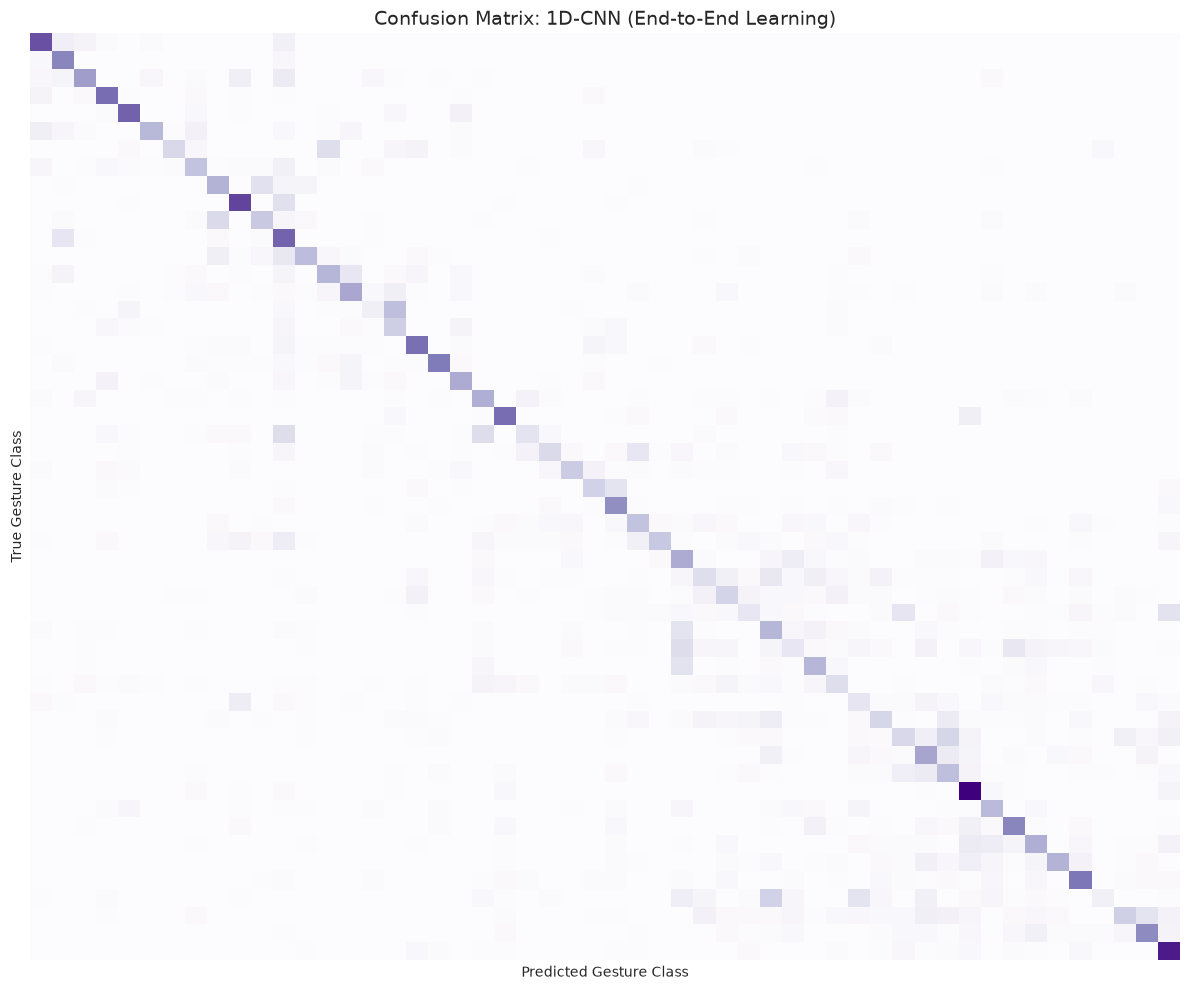

In [11]:
conf_matrix_cnn = confusion_matrix(y_test, cnn_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_cnn, cmap='Purples', cbar=False, 
            xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix: 1D-CNN (End-to-End Learning)", fontsize=14)
plt.xlabel("Predicted Gesture Class")
plt.ylabel("True Gesture Class")
plt.tight_layout()
plt.show()